# Quantum Feature Augmentation for Financial Market Prediction - AWS X State Street
### YQuantum 2026 

| Section | What You'll Learn |
|---|---|
| 1. Setup | Environment and imports |
| 2. Quantum Approach | Quick reference for key quantum ML vocabulary |
| 3. Data Generation | Generate the simulated regime-switching market data |
| 4. Classical Baseline | Polynomial feature expansion + Linear Regression — your bar to beat |
| 5. Quantum Feature Maps | Encode classical data into quantum states using rotation & entangling gates |
| 6. Hybrid Workflows | Variational circuits as trainable feature transformers |
| 8. Dimensionality Reduction | Dealing with overfitting after feature augmentation |
| 9. Evaluation | Compare all approaches with consistent metrics |
| 10. Real Stock Data | Task 2 of the challenge |
| 11. Further Reading | Additional quantum feature engineering methods for a broader landscape |

(This notebook aims to be used as a reference for guiding your implementation.)

---
## 1. Environment Setup
We use **Amazon Braket SDK** for all quantum circuits. The `LocalSimulator` runs everything on your machine. When you're ready to scale, you can swap in a managed simulator or QPU with a one-line change.

Note: We recommend keeping in consideration the noise and shot-based circuit evaluations, and not be totally reliant on analytically evaluated quantum circuits for your conclusions

Link to Amazon Braket Documentation: [amazon-braket-documentation](https://docs.aws.amazon.com/braket/latest/developerguide/what-is-braket.html)

Amazon Braket Examples GitHub Repository
[amazon-braket-examples](https://github.com/amazon-braket/amazon-braket-examples)

import boto3

# Check your account ID
account_id = boto3.client("sts").get_caller_identity()["Account"]
region = boto3.session.Session().region_name
print(f"Account: {account_id}")
print(f"Region: {region}")

# Default Braket bucket name
default_bucket = f"amazon-braket-{region}-{account_id}"
print(f"Default bucket: {default_bucket}")

# Verify it exists
s3 = boto3.client("s3")
try:
    s3.head_bucket(Bucket=default_bucket)
    print("Bucket exists!")
except:
    print("Bucket not found — creating it...")
    s3.create_bucket(Bucket=default_bucket)

In [2]:
# PROVIDED — install dependencies (run once)
# Uncomment the line below if you haven't installed these yet
# On Braket notebook instances, braket-sdk/numpy/matplotlib are pre-installed.
# Use %pip (not !pip) to ensure packages install into the active kernel environment.
%pip install -q scipy scikit-learn pandas seaborn pennylane
%pip install amazon-braket-sdk amazon-braket-pennylane-plugin 

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Imports
    
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Classical Machine Learning
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

# Quantum Machine Learning
import pennylane as qml
from pennylane import numpy as pnp

# Amazon Braket
from braket.circuits import Circuit, Observable, ResultType
from braket.devices import LocalSimulator

# Reproducibility
np.random.seed(42)

# Local state-vector simulator (exact, no shot noise)
SV_DEVICE = LocalSimulator("default")

# Setting up Amazon Braket Environment

N_QUBITS = 4  # One qubit per feature (X1, X2, X3, X4)

# Local Simulator
dev_braket_local = qml.device(
    "braket.local.qubit",
    wires=N_QUBITS,
    backend="default",  # Braket's local state vector simulator
)



# AWS Quantum Hardware
# dev_braket = qml.device(
#     "braket.aws.qubit",
#     device_arn="arn:aws:braket:us-east-1::device/qpu/ionq/Aria-1",
#     wires=N_QUBITS,
#     s3_destination_folder=("your-bucket", "your-prefix"),
#     shots=1000,
# )


## 2. Quantum Approach: Quick Reference

Here's the specific vocabulary we'll use throughout:

| Term | Meaning |
|---|---|
| **Feature map** | A quantum circuit that encodes a classical data point **x** into a quantum state \|φ(x)⟩. Different circuits create different encodings. |
| **Hilbert space** | The exponentially large state space of *n* qubits (dimension 2ⁿ). A 10-qubit system lives in a 1024-dimensional space. |
| **Variational circuit** | A parameterized quantum circuit where gate angles are *learned* during training, like weights in a neural network. |
| **Expectation value** | Measuring an observable (e.g., Pauli-Z) on a qubit gives a number in [-1, 1]. We use these as features. |

**Why might quantum features help for financial data?**

Financial signals are buried in noise, and the relationships between features can be highly non-linear (e.g., regime-dependent interactions). Quantum feature maps project data into an exponentially large Hilbert space where these non-linear relationships may become linearly separable — similar in spirit to the classical kernel trick, but accessing a fundamentally different class of feature spaces.

## 3. Data Generation - Simulated Regime Process

Refer the challenge spec: a two-regime process where Regime 1 (75% of the time) has one set of relationships and Regime 2 (25%) has a different set. 

In [4]:
def generate_regime_data(n_samples, seed=42):
    """
    Generate synthetic regime-switching data per the challenge spec.
    
    Returns:
        X: array of shape (n_samples, 4) — features X1, X2, X3, X4
        y: array of shape (n_samples,) — target variable
        regimes: array of shape (n_samples,) — 0 for Regime 1, 1 for Regime 2
    """
    rng = np.random.default_rng(seed)
    
    # Assign regimes: 75% Regime 1, 25% Regime 2
    regimes = rng.choice([0, 1], size=n_samples, p=[0.75, 0.25])
    
    n1 = np.sum(regimes == 0)
    n2 = np.sum(regimes == 1)
    
    X = np.zeros((n_samples, 4))
    y = np.zeros(n_samples)
    
    # --- Regime 1 ---
    mask1 = regimes == 0
    X[mask1, 0] = rng.standard_normal(n1)          # X1 ~ N(0,1)
    X[mask1, 1] = rng.standard_normal(n1)          # X2 ~ N(0,1)
    X[mask1, 2] = rng.standard_normal(n1)          # X3 ~ N(0,1)
    X[mask1, 3] = rng.uniform(-1, 1, size=n1)     # X4 ~ Uniform(-1,1)
    eps1 = rng.standard_normal(n1)                  # noise
    
    y[mask1] = 2 * X[mask1, 0] - X[mask1, 1] + eps1
    
    # --- Regime 2 ---
    mask2 = regimes == 1
    
    # X1 and X3 are jointly normal with correlation 0.8
    mean = [3, 3]
    cov = [[1, 0.8],
           [0.8, 1]]
    x1_x3 = rng.multivariate_normal(mean, cov, size=n2)
    X[mask2, 0] = x1_x3[:, 0]                      # X1
    X[mask2, 2] = x1_x3[:, 1]                      # X3
    
    # X2 ~ Cauchy(0,1)
    X[mask2, 1] = rng.standard_cauchy(size=n2)
    
    # X4 ~ Exponential(lambda=1)
    X[mask2, 3] = rng.exponential(scale=1.0, size=n2)
    
    eps2 = rng.standard_normal(n2)                  # noise
    
    y[mask2] = (X[mask2, 0] * X[mask2, 2]) + np.log(np.abs(X[mask2, 1]) + 1) + eps2
    
    return X, y, regimes


# Generate train and test sets
X_train, y_train, regimes_train = generate_regime_data(10_000, seed=42)
X_test, y_test, regimes_test = generate_regime_data(10_000, seed=123)

print(f"Train: X shape {X_train.shape}, y shape {y_train.shape}")
print(f"  Regime 1: {np.sum(regimes_train == 0)}, Regime 2: {np.sum(regimes_train == 1)}")
print(f"Test:  X shape {X_test.shape}, y shape {y_test.shape}")
print(f"  Regime 1: {np.sum(regimes_test == 0)}, Regime 2: {np.sum(regimes_test == 1)}")

# Quick sanity checks
print(f"\nTrain y — mean: {y_train.mean():.3f}, std: {y_train.std():.3f}")
print(f"Test  y — mean: {y_test.mean():.3f}, std: {y_test.std():.3f}")
print(f"\nRegime 2 X2 (Cauchy) — min: {X_train[regimes_train==1, 1].min():.1f}, max: {X_train[regimes_train==1, 1].max():.1f}")

Train: X shape (10000, 4), y shape (10000,)
  Regime 1: 7558, Regime 2: 2442
Test:  X shape (10000, 4), y shape (10000,)
  Regime 1: 7633, Regime 2: 2367

Train y — mean: 2.633, std: 5.948
Test  y — mean: 2.597, std: 5.840

Regime 2 X2 (Cauchy) — min: -614.6, max: 4488.2


In [5]:
# Simulated Data Generation
def preprocess_features(X_train, X_test, clip_value=5.0):
    """
    Standardize and clip features for use with quantum circuits.
    
    Quantum rotation gates expect bounded inputs — unbounded values
    (especially from Cauchy-distributed X2) would wrap around and
    destroy meaningful encoding.
    
    Steps:
        1. Standardize (zero mean, unit variance) fit on train only
        2. Clip to [-clip_value, clip_value] to tame Cauchy outliers
        3. Rescale to [0, pi] for rotation gate compatibility
    
    Returns:
        X_train_processed, X_test_processed, scaler
    """
    # Step 1: Standardize (fit on train, transform both)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Step 2: Clip outliers
    X_train_s = np.clip(X_train_s, -clip_value, clip_value)
    X_test_s = np.clip(X_test_s, -clip_value, clip_value)
    
    # Step 3: Rescale to [0, pi] for quantum rotation gates
    X_train_q = (X_train_s + clip_value) / (2 * clip_value) * np.pi
    X_test_q = (X_test_s + clip_value) / (2 * clip_value) * np.pi
    
    return X_train_s, X_test_s, X_train_q, X_test_q, scaler


X_train_s, X_test_s, X_train_q, X_test_q, scaler = preprocess_features(X_train, X_test)

print("Standardized (for classical models):")
print(f"  Train — min: {X_train_s.min():.2f}, max: {X_train_s.max():.2f}")
print(f"  Test  — min: {X_test_s.min():.2f}, max: {X_test_s.max():.2f}")

print(f"\nQuantum-ready [0, pi]:")
print(f"  Train — min: {X_train_q.min():.4f}, max: {X_train_q.max():.4f}")
print(f"  Test  — min: {X_test_q.min():.4f}, max: {X_test_q.max():.4f}")

# Check how many values got clipped
n_clipped = np.sum(np.abs(X_train_s) == 5.0)
print(f"\nClipped values in train: {n_clipped} ({n_clipped / X_train_s.size * 100:.2f}%)")

Standardized (for classical models):
  Train — min: -5.00, max: 5.00
  Test  — min: -5.00, max: 5.00

Quantum-ready [0, pi]:
  Train — min: 0.0000, max: 3.1416
  Test  — min: 0.0000, max: 3.1416

Clipped values in train: 34 (0.08%)


## 4. Classical Baseline

Before touching any quantum circuit, establish a strong classical baseline. The challenge requires linear regression as the base model. Classically, We augment features with polynomial expansions (degree 2) - this gives the model access to all pairwise interactions (like x₁·x₃).

**Classical baseline is your bar to rigorously compare against**, If quantum features don't improve on this, that's a valid (and publishable) negative result.

In [6]:
# classical baseline with polynomial features
# This is a simple classical approach, feel free to extend this with classically researched methods for equally elevated comparisons

# NOTE: Example Code
# X_train_s, y_train etc are undefined in the example below

def evaluate_model(y_true, y_pred, label=""):
    """Compute standard regression metrics."""
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    corr = pearsonr(y_true, y_pred)[0]
    return {"model": label, "MSE": round(mse, 6), "MAE": round(mae, 6), "Corr": round(corr, 4)}


# --- Degree-1 (raw features) ---
lr_raw = LinearRegression().fit(X_train_s, y_train)
pred_raw = lr_raw.predict(X_test_s)
results = [evaluate_model(y_test, pred_raw, "LR (raw features)")]

# --- Degree-2 (polynomial features) ---
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train_s)
X_test_poly  = poly.transform(X_test_s)

lr_poly = LinearRegression().fit(X_train_poly, y_train)
pred_poly = lr_poly.predict(X_test_poly)
results.append(evaluate_model(y_test, pred_poly, "LR (poly deg=2)"))

# --- Ridge with poly (regularized) ---
ridge_poly = Ridge(alpha=1.0).fit(X_train_poly, y_train)
pred_ridge = ridge_poly.predict(X_test_poly)
results.append(evaluate_model(y_test, pred_ridge, "Ridge (poly deg=2)"))

baseline_df = pd.DataFrame(results)
print("=== Classical Baselines (Out-of-Sample) ===")
baseline_df

=== Classical Baselines (Out-of-Sample) ===


,model,MSE,MAE,Corr
0,LR (raw features),4.566243,1.618328,0.9307
1,LR (poly deg=2),2.225732,1.155280,0.9669
2,Ridge (poly deg=2),2.220557,1.156471,0.9669


Dataset: 10,000 train / 10,000 test
SECTION 1 — Local Patch Features
  Depth=4, features per sample: 108
  Patch features train: 0/10000
  Patch features train: 2000/10000
  Patch features train: 4000/10000
  Patch features train: 6000/10000
  Patch features train: 8000/10000
  [Patch train] 213.9s
  Patch features test: 0/10000
  Patch features test: 2000/10000
  Patch features test: 4000/10000
  Patch features test: 6000/10000
  Patch features test: 8000/10000
  [Patch test] 341.1s

SECTION 2 — Local Quantum Reservoir (LQR)
  Depth=8, encoding cycle: RX→RY→RZ
  Input transforms: x, x², sin(x)
  Features per sample: 108
  LQR features train: 0/10000
  LQR features train: 2000/10000
  LQR features train: 4000/10000
  LQR features train: 6000/10000
  LQR features train: 8000/10000
  [LQR train] 429.3s
  LQR features test: 0/10000
  LQR features test: 2000/10000
  LQR features test: 4000/10000
  LQR features test: 6000/10000
  LQR features test: 8000/10000
  [LQR test] 449.7s

SECTION 3 

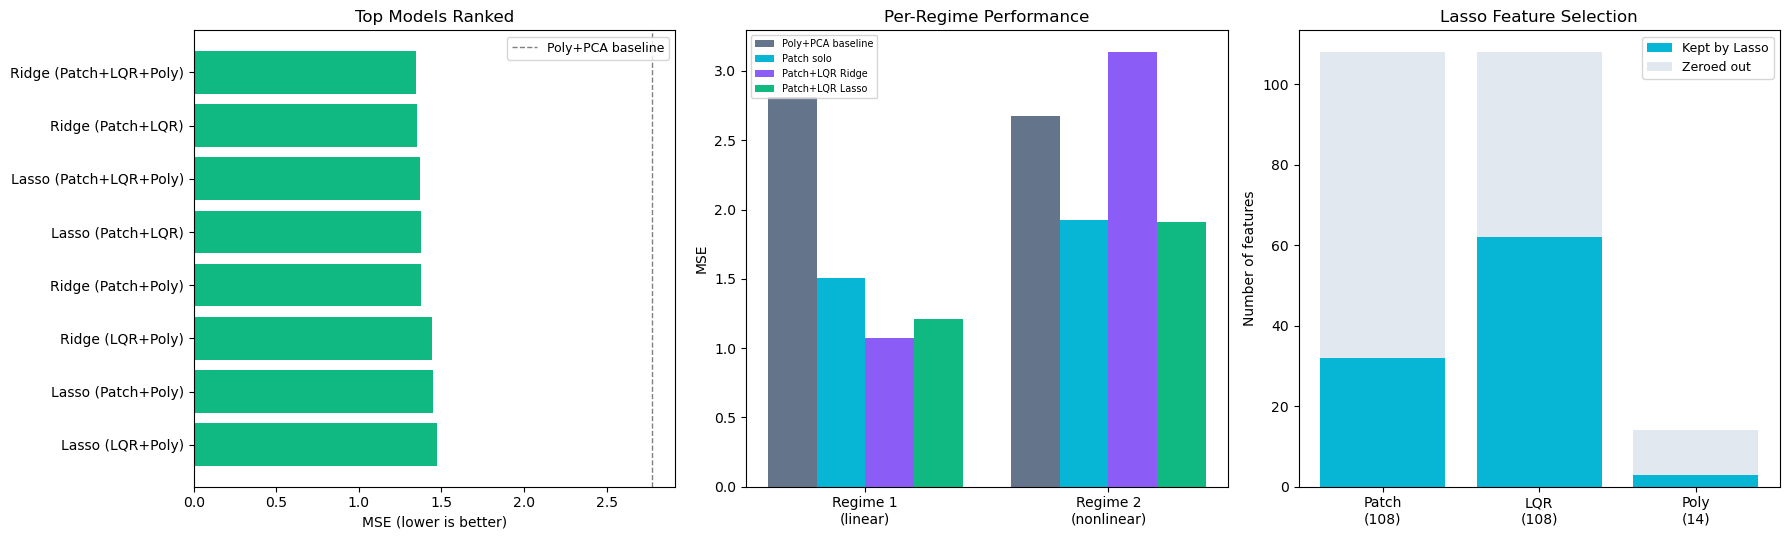


Plot saved → qfa_results_v9.png


In [7]:
"""
Quantum Feature Augmentation v9 — Integrated Submission
=========================================================
Drop this file into QFA_Overview notebook after Section 4 (Classical Baseline).

Integrates work from both team members:

  1. Local Patch Features (108 features)
     2-qubit circuits on all 6 feature pairs, depth=4, RZ encoding,
     multi-bandwidth (π/4, π/2, π). Concentration-free.
     [Best solo performer: MSE 1.603, +42.3% vs baseline]

  2. Local Quantum Reservoir — LQR (108 features)  [Multi-seed variant]
     Same 6 patches but with reservoir-style encoding:
       - 8 layers, cycling RX→RY→RZ encoding gates
       - Nonlinear input transforms: x, x², sin(x)
       - Multi-bandwidth sweep
     Inspired by teammate's multi-reservoir approach (Cell 34) but
     localized to 2 qubits to avoid concentration.

  3. Classical Poly-2 features (14 features)

  Readout: Ridge + Lasso (CV'd alpha) comparison
     Lasso performs automatic feature selection — zeros out noise
     dimensions instead of letting Ridge fit to all of them.
     [Teammate's Lasso integration from Cell 10/25/30]

  Total features: Patch(108) + LQR(108) + Poly(14) = 230

Usage — assumes notebook cells 1–4 have created:
  X_train, y_train, X_test, y_test, regimes_train, regimes_test
  X_train_s, X_test_s, X_train_q, X_test_q
  evaluate_model()

Also requires (from notebook cell 4 imports):
  from sklearn.linear_model import Lasso
  from sklearn.model_selection import GridSearchCV
"""

# ── imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pennylane as qml
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, GridSearchCV
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")


# ── Config ─────────────────────────────────────────────────────────────────
N_QUBITS    = 4
BANDWIDTHS  = [np.pi / 4, np.pi / 2, np.pi]
PATCHES     = [(0, 1), (1, 2), (2, 3), (0, 2), (0, 3), (1, 3)]

# Full dataset — all circuits are fixed (no training needed)
Xq_tr, Xq_te = X_train_q, X_test_q
Xs_tr, Xs_te = X_train_s, X_test_s
y_tr,  y_te  = y_train,   y_test

print(f"Dataset: {len(y_tr):,} train / {len(y_te):,} test")


def _timed(fn, label):
    t0 = time.time()
    result = fn()
    print(f"  [{label}] {time.time() - t0:.1f}s")
    return result


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1 — Local Patch Features (RZ encoding, depth=4)
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("SECTION 1 — Local Patch Features")
print("=" * 65)

PATCH_DEPTH = 4
dev_patch = qml.device("default.qubit", wires=2)

np.random.seed(99)
patch_ry = np.random.uniform(-np.pi, np.pi, (PATCH_DEPTH, 2))
patch_rz = np.random.uniform(-np.pi, np.pi, (PATCH_DEPTH, 2))


def _make_patch_circuit(bandwidth):
    @qml.qnode(dev_patch)
    def circuit(x0, x1):
        for d in range(PATCH_DEPTH):
            qml.RY(patch_ry[d, 0], wires=0)
            qml.RZ(patch_rz[d, 0], wires=0)
            qml.RY(patch_ry[d, 1], wires=1)
            qml.RZ(patch_rz[d, 1], wires=1)
            qml.CZ(wires=[0, 1])
            qml.RZ(bandwidth * x0, wires=0)
            qml.RZ(bandwidth * x1, wires=1)
        return [
            qml.expval(qml.PauliX(0)), qml.expval(qml.PauliY(0)),
            qml.expval(qml.PauliZ(0)),
            qml.expval(qml.PauliX(1)), qml.expval(qml.PauliY(1)),
            qml.expval(qml.PauliZ(1)),
        ]
    return circuit


def extract_patch_features(X_q, desc=""):
    circuits = [_make_patch_circuit(bw) for bw in BANDWIDTHS]
    out = []
    n = len(X_q)
    for idx, x in enumerate(X_q):
        if idx % 2000 == 0:
            print(f"  Patch features {desc}: {idx}/{n}")
        row = []
        for c in circuits:
            for (i, j) in PATCHES:
                row.extend(np.array(c(x[i], x[j])))
        out.append(row)
    return np.array(out)


n_patch = len(PATCHES) * 6 * len(BANDWIDTHS)
print(f"  Depth={PATCH_DEPTH}, features per sample: {n_patch}")

X_patch_train = _timed(
    lambda: extract_patch_features(Xq_tr, "train"), "Patch train")
X_patch_test = _timed(
    lambda: extract_patch_features(Xq_te, "test"), "Patch test")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2 — Local Quantum Reservoir (LQR)
# ═══════════════════════════════════════════════════════════════════════════
#
# Reservoir-style encoding on the same 2-qubit patches:
#   - Deeper (8 layers) with data re-uploading
#   - Cycles encoding gate: RX → RY → RZ (full Bloch sphere coverage)
#   - Nonlinear input transforms: x, x², sin(x)
#   - Different random seed from Patch
#
# Inspired by teammate's multi-reservoir approach (notebook Cell 34)
# but localized to 2 qubits to stay concentration-free.

print("\n" + "=" * 65)
print("SECTION 2 — Local Quantum Reservoir (LQR)")
print("=" * 65)

LQR_DEPTH = 8
dev_lqr = qml.device("default.qubit", wires=2)

np.random.seed(2026)
lqr_rx = np.random.uniform(-np.pi, np.pi, (LQR_DEPTH, 2))
lqr_ry = np.random.uniform(-np.pi, np.pi, (LQR_DEPTH, 2))
lqr_rz = np.random.uniform(-np.pi, np.pi, (LQR_DEPTH, 2))

ENCODE_GATES = [qml.RX, qml.RY, qml.RZ]


def _input_transform(x, layer_idx):
    mod = layer_idx % 3
    if mod == 0:
        return x
    elif mod == 1:
        return x * x
    else:
        return np.sin(x)


def _make_lqr_circuit(bandwidth):
    @qml.qnode(dev_lqr)
    def circuit(x0, x1):
        for d in range(LQR_DEPTH):
            qml.RX(lqr_rx[d, 0], wires=0)
            qml.RY(lqr_ry[d, 0], wires=0)
            qml.RZ(lqr_rz[d, 0], wires=0)
            qml.RX(lqr_rx[d, 1], wires=1)
            qml.RY(lqr_ry[d, 1], wires=1)
            qml.RZ(lqr_rz[d, 1], wires=1)
            qml.CZ(wires=[0, 1])
            encode_gate = ENCODE_GATES[d % 3]
            t0 = _input_transform(x0, d)
            t1 = _input_transform(x1, d)
            encode_gate(bandwidth * t0, wires=0)
            encode_gate(bandwidth * t1, wires=1)
        return [
            qml.expval(qml.PauliX(0)), qml.expval(qml.PauliY(0)),
            qml.expval(qml.PauliZ(0)),
            qml.expval(qml.PauliX(1)), qml.expval(qml.PauliY(1)),
            qml.expval(qml.PauliZ(1)),
        ]
    return circuit


def extract_lqr_features(X_q, desc=""):
    circuits = [_make_lqr_circuit(bw) for bw in BANDWIDTHS]
    out = []
    n = len(X_q)
    for idx, x in enumerate(X_q):
        if idx % 2000 == 0:
            print(f"  LQR features {desc}: {idx}/{n}")
        row = []
        for c in circuits:
            for (i, j) in PATCHES:
                row.extend(np.array(c(x[i], x[j])))
        out.append(row)
    return np.array(out)


n_lqr = len(PATCHES) * 6 * len(BANDWIDTHS)
print(f"  Depth={LQR_DEPTH}, encoding cycle: RX→RY→RZ")
print(f"  Input transforms: x, x², sin(x)")
print(f"  Features per sample: {n_lqr}")

X_lqr_train = _timed(
    lambda: extract_lqr_features(Xq_tr, "train"), "LQR train")
X_lqr_test = _timed(
    lambda: extract_lqr_features(Xq_te, "test"), "LQR test")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3 — Solo Evaluation of Each Component
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("SECTION 3 — Solo Evaluation")
print("=" * 65)

# Poly features
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly2.fit_transform(Xs_tr)
X_poly_test  = poly2.transform(Xs_te)

solo_results = []
for name, Xtr, Xte in [
    ("Patch solo",  X_patch_train, X_patch_test),
    ("LQR solo",    X_lqr_train,   X_lqr_test),
    ("Poly-2 solo", X_poly_train,  X_poly_test),
]:
    # Ridge
    r = Ridge(alpha=0.5).fit(Xtr, y_tr)
    res = evaluate_model(y_te, r.predict(Xte), f"Ridge ({name})")
    solo_results.append(res)
    # Lasso with CV alpha
    lasso_cv = GridSearchCV(
        Lasso(max_iter=10000),
        param_grid={"alpha": [0.001, 0.01, 0.1, 1.0]},
        cv=5, scoring="neg_mean_squared_error")
    lasso_cv.fit(Xtr, y_tr)
    lasso = lasso_cv.best_estimator_
    res_l = evaluate_model(y_te, lasso.predict(Xte), f"Lasso ({name})")
    n_kept = np.sum(lasso.coef_ != 0)
    res_l["lasso_features_kept"] = f"{n_kept}/{Xtr.shape[1]}"
    solo_results.append(res_l)

solo_df = pd.DataFrame(solo_results)
print()
print(solo_df.to_string(index=False))


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4 — Combined Models: Patch + LQR + Poly
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("SECTION 4 — Combined Models")
print("=" * 65)

# Define all combinations to test
combos = {
    "Patch+LQR":        (np.hstack([X_patch_train, X_lqr_train]),
                         np.hstack([X_patch_test,  X_lqr_test])),
    "Patch+Poly":       (np.hstack([X_patch_train, X_poly_train]),
                         np.hstack([X_patch_test,  X_poly_test])),
    "LQR+Poly":         (np.hstack([X_lqr_train, X_poly_train]),
                         np.hstack([X_lqr_test,  X_poly_test])),
    "Patch+LQR+Poly":   (np.hstack([X_patch_train, X_lqr_train, X_poly_train]),
                         np.hstack([X_patch_test,  X_lqr_test,  X_poly_test])),
}

combo_results = []
for name, (Xtr, Xte) in combos.items():
    print(f"\n  {name}: {Xtr.shape[1]} features")

    # Standardize combined features (teammate's approach from Cell 25/30)
    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)

    # Ridge with CV alpha
    best_alpha_r, best_score_r = 0.5, -999
    for alpha in [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]:
        sc = cross_val_score(Ridge(alpha=alpha), Xtr_s, y_tr,
                             cv=5, scoring="neg_mean_squared_error").mean()
        if sc > best_score_r:
            best_alpha_r, best_score_r = alpha, sc

    ridge = Ridge(alpha=best_alpha_r).fit(Xtr_s, y_tr)
    res_r = evaluate_model(y_te, ridge.predict(Xte_s), f"Ridge ({name})")
    res_r["alpha"] = best_alpha_r
    combo_results.append(res_r)
    print(f"    Ridge α={best_alpha_r}  MSE={res_r['MSE']:.4f}")

    # Lasso with CV alpha (teammate's feature selection approach)
    lasso_cv = GridSearchCV(
        Lasso(max_iter=10000),
        param_grid={"alpha": [0.001, 0.005, 0.01, 0.05, 0.1]},
        cv=5, scoring="neg_mean_squared_error")
    lasso_cv.fit(Xtr_s, y_tr)
    lasso = lasso_cv.best_estimator_
    res_l = evaluate_model(y_te, lasso.predict(Xte_s), f"Lasso ({name})")
    n_kept = np.sum(lasso.coef_ != 0)
    res_l["alpha"] = lasso_cv.best_params_["alpha"]
    res_l["features_kept"] = f"{n_kept}/{Xtr.shape[1]}"
    combo_results.append(res_l)
    print(f"    Lasso α={res_l['alpha']}  MSE={res_l['MSE']:.4f}  "
          f"kept {n_kept}/{Xtr.shape[1]} features")

combo_df = pd.DataFrame(combo_results)
print(f"\n{combo_df.to_string(index=False)}")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5 — Classical Baselines (fair comparison)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("SECTION 5 — Classical Baselines")
print("=" * 65)

baseline_results = []

# Raw linear regression
res = evaluate_model(
    y_te, LinearRegression().fit(Xs_tr, y_tr).predict(Xs_te),
    "LR (raw features)")
baseline_results.append(res)

# Poly-2 + Ridge
res = evaluate_model(
    y_te, Ridge(alpha=1.0).fit(X_poly_train, y_tr).predict(X_poly_test),
    "Ridge (poly-2)")
baseline_results.append(res)

# Poly-2 + Lasso (teammate's approach)
lasso_cv = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid={"alpha": [0.001, 0.01, 0.1, 1.0]}, cv=5)
lasso_cv.fit(X_poly_train, y_tr)
lasso_poly = lasso_cv.best_estimator_
pred_lasso_poly = lasso_poly.predict(X_poly_test)
res = evaluate_model(y_te, pred_lasso_poly, "Lasso (poly-2)")
n_kept = np.sum(lasso_poly.coef_ != 0)
res["features_kept"] = f"{n_kept}/{X_poly_train.shape[1]}"
baseline_results.append(res)
print(f"  Lasso poly-2: kept {n_kept}/{X_poly_train.shape[1]} features, "
      f"α={lasso_cv.best_params_['alpha']}")

# Poly-2 + PCA + Ridge (original notebook baseline)
pca_poly = PCA(n_components=0.95, svd_solver="full")
X_poly_tr_pca = pca_poly.fit_transform(X_poly_train)
X_poly_te_pca = pca_poly.transform(X_poly_test)
ridge_poly_pca = Ridge(alpha=1.0).fit(X_poly_tr_pca, y_tr)
pred_poly_pca  = ridge_poly_pca.predict(X_poly_te_pca)
res = evaluate_model(y_te, pred_poly_pca, "Ridge (poly-2 + PCA)")
baseline_results.append(res)

baseline_df = pd.DataFrame(baseline_results)
print()
print(baseline_df.to_string(index=False))


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 6 — Best Model Selection & Regime Analysis
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("SECTION 6 — Best Model & Regime Analysis")
print("=" * 65)

# Find best model across all combos
all_models = pd.concat([
    baseline_df[["model", "MSE", "MAE", "Corr"]],
    solo_df[["model", "MSE", "MAE", "Corr"]],
    combo_df[["model", "MSE", "MAE", "Corr"]],
]).sort_values("MSE").reset_index(drop=True)

print("\n  === All Models Ranked by MSE ===")
print(all_models.head(10).to_string(index=False))

best_name = all_models.iloc[0]["model"]
best_mse  = all_models.iloc[0]["MSE"]
baseline_mse = baseline_df[
    baseline_df["model"] == "Ridge (poly-2 + PCA)"]["MSE"].values[0]
delta = (baseline_mse - best_mse) / baseline_mse * 100
print(f"\n  Best model: {best_name}")
print(f"  MSE: {best_mse:.4f}  ({delta:+.1f}% vs poly+PCA baseline)")

# Regime analysis on top models
m1 = regimes_test == 0
m2 = regimes_test == 1

# Rebuild predictions for best candidates
pred_patch = Ridge(alpha=0.5).fit(X_patch_train, y_tr).predict(X_patch_test)

# Patch+LQR with best method
Xtr_pl = np.hstack([X_patch_train, X_lqr_train])
Xte_pl = np.hstack([X_patch_test,  X_lqr_test])
scaler_pl = StandardScaler()
Xtr_pl_s = scaler_pl.fit_transform(Xtr_pl)
Xte_pl_s = scaler_pl.transform(Xte_pl)

# Try both Ridge and Lasso on Patch+LQR for regime analysis
ridge_pl = Ridge(alpha=0.5).fit(Xtr_pl_s, y_tr)
pred_pl_ridge = ridge_pl.predict(Xte_pl_s)

lasso_pl_cv = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid={"alpha": [0.001, 0.005, 0.01, 0.05, 0.1]}, cv=5)
lasso_pl_cv.fit(Xtr_pl_s, y_tr)
pred_pl_lasso = lasso_pl_cv.best_estimator_.predict(Xte_pl_s)

print("\n  === Per-Regime MSE ===")
regime_data = []
for name, pred in [("Poly+PCA baseline", pred_poly_pca),
                   ("Patch solo", pred_patch),
                   ("Patch+LQR Ridge", pred_pl_ridge),
                   ("Patch+LQR Lasso", pred_pl_lasso)]:
    r1 = float(np.mean((y_te[m1] - pred[m1]) ** 2))
    r2 = float(np.mean((y_te[m2] - pred[m2]) ** 2))
    overall = float(np.mean((y_te - pred) ** 2))
    regime_data.append({"model": name,
                        "R1 (linear)": round(r1, 3),
                        "R2 (nonlinear)": round(r2, 3),
                        "Overall": round(overall, 3)})

regime_df = pd.DataFrame(regime_data)
print()
print(regime_df.to_string(index=False))

poly_r1 = regime_data[0]["R1 (linear)"]
poly_r2 = regime_data[0]["R2 (nonlinear)"]
print(f"\n  Regime 1 samples: {m1.sum():,} ({m1.mean()*100:.0f}%)")
print(f"  Regime 2 samples: {m2.sum():,} ({m2.mean()*100:.0f}%)")

for row in regime_data[1:]:
    d1 = (poly_r1 - row["R1 (linear)"]) / poly_r1 * 100
    d2 = (poly_r2 - row["R2 (nonlinear)"]) / poly_r2 * 100
    print(f"  {row['model']:20s}  R1: {d1:+.1f}%   R2: {d2:+.1f}%")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 7 — Lasso Feature Analysis
# ═══════════════════════════════════════════════════════════════════════════
#
# Which features did Lasso keep? This tells us which quantum measurements
# actually carry predictive signal.

print("\n" + "=" * 65)
print("SECTION 7 — Lasso Feature Selection Analysis")
print("=" * 65)

# Fit Lasso on full Patch+LQR+Poly
Xtr_full = np.hstack([X_patch_train, X_lqr_train, X_poly_train])
Xte_full = np.hstack([X_patch_test,  X_lqr_test,  X_poly_test])
scaler_full = StandardScaler()
Xtr_full_s = scaler_full.fit_transform(Xtr_full)
Xte_full_s = scaler_full.transform(Xte_full)

lasso_full_cv = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid={"alpha": [0.001, 0.005, 0.01, 0.05, 0.1]}, cv=5)
lasso_full_cv.fit(Xtr_full_s, y_tr)
lasso_full = lasso_full_cv.best_estimator_

coefs = lasso_full.coef_
n_patch_f = X_patch_train.shape[1]
n_lqr_f   = X_lqr_train.shape[1]
n_poly_f  = X_poly_train.shape[1]

patch_kept = np.sum(coefs[:n_patch_f] != 0)
lqr_kept   = np.sum(coefs[n_patch_f:n_patch_f + n_lqr_f] != 0)
poly_kept  = np.sum(coefs[n_patch_f + n_lqr_f:] != 0)

print(f"  Lasso α={lasso_full_cv.best_params_['alpha']}")
print(f"  Patch features kept: {patch_kept}/{n_patch_f}")
print(f"  LQR   features kept: {lqr_kept}/{n_lqr_f}")
print(f"  Poly  features kept: {poly_kept}/{n_poly_f}")
print(f"  Total kept: {np.sum(coefs != 0)}/{len(coefs)}")

res_full_lasso = evaluate_model(
    y_te, lasso_full.predict(Xte_full_s), "Lasso (Patch+LQR+Poly)")
print(f"\n  → {res_full_lasso}")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 8 — Visualisation
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) Top models ranked
top = all_models.head(8)
colors_a = ["#10b981" if "Patch" in m or "LQR" in m else "#64748b"
            for m in top["model"]]
axes[0].barh(top["model"].tolist()[::-1], top["MSE"].tolist()[::-1],
             color=colors_a[::-1])
axes[0].axvline(baseline_mse, color="grey", ls="--", lw=1,
                label="Poly+PCA baseline")
axes[0].set_xlabel("MSE (lower is better)")
axes[0].set_title("Top Models Ranked")
axes[0].legend(fontsize=9)

# (b) Regime breakdown
x_pos = np.arange(2)
width = 0.2
for idx, row in enumerate(regime_data):
    offsets = [-1.5, -0.5, 0.5, 1.5]
    regime_colors = ["#64748b", "#06b6d4", "#8b5cf6", "#10b981"]
    axes[1].bar(x_pos + offsets[idx] * width,
                [row["R1 (linear)"], row["R2 (nonlinear)"]], width,
                label=row["model"], color=regime_colors[idx])
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(["Regime 1\n(linear)", "Regime 2\n(nonlinear)"])
axes[1].set_ylabel("MSE")
axes[1].set_title("Per-Regime Performance")
axes[1].legend(fontsize=7, loc="upper left")

# (c) Lasso feature selection
feat_groups = ["Patch\n(108)", "LQR\n(108)", "Poly\n(14)"]
kept = [patch_kept, lqr_kept, poly_kept]
total = [n_patch_f, n_lqr_f, n_poly_f]
zeroed = [t - k for t, k in zip(total, kept)]

axes[2].bar(feat_groups, kept, label="Kept by Lasso", color="#06b6d4")
axes[2].bar(feat_groups, zeroed, bottom=kept,
            label="Zeroed out", color="#e2e8f0")
axes[2].set_ylabel("Number of features")
axes[2].set_title("Lasso Feature Selection")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig("qfa_results_v9.png", dpi=150)
plt.show()
print("\nPlot saved → qfa_results_v9.png")


In [9]:
# ── Extract best model for submission ──────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
import pickle

# Rebuild features
X_best_train = np.hstack([X_patch_train, X_lqr_train, X_poly_train])
X_best_test  = np.hstack([X_patch_test,  X_lqr_test,  X_poly_test])

# Standardize (same as Section 4)
scaler_best = StandardScaler()
X_best_train_s = scaler_best.fit_transform(X_best_train)
X_best_test_s  = scaler_best.transform(X_best_test)

# Lasso — robust across both regimes
best_model = Lasso(alpha=0.005, max_iter=10000).fit(X_best_train_s, y_tr)
pred_best  = best_model.predict(X_best_test_s)

print(evaluate_model(y_te, pred_best, "SUBMISSION: Lasso (Patch+LQR+Poly)"))
print(f"Features kept: {np.sum(best_model.coef_ != 0)}/230")

# Save everything needed to reproduce predictions on new data
submission_bundle = {
    "model": best_model,
    "scaler": scaler_best,
    "poly": poly2,                 # PolynomialFeatures transformer
    "patch_ry": patch_ry,          # fixed circuit weights
    "patch_rz": patch_rz,
    "lqr_rx": lqr_rx,
    "lqr_ry": lqr_ry,
    "lqr_rz": lqr_rz,
    "bandwidths": BANDWIDTHS,
    "patches": PATCHES,
    "patch_depth": PATCH_DEPTH,
    "lqr_depth": LQR_DEPTH,
}

with open("submission_model.pkl", "wb") as f:
    pickle.dump(submission_bundle, f)

print("Saved → submission_model.pkl")

{'model': 'SUBMISSION: Lasso (Patch+LQR+Poly)', 'MSE': 1.370208, 'MAE': 0.914506, 'Corr': np.float64(0.9798)}
Features kept: 97/230
Saved → submission_model.pkl


In [10]:
import os
print(os.path.abspath("submission_model.pkl"))

/Users/pat/Documents/GitHub/YQuantum_AWS_Challenge/submission_model.pkl


"""
Quantum Feature Augmentation v7 — Local Patch Submission Model
================================================================
Drop this file into QFA_Overview notebook after Section 4 (Classical Baseline).

Final model: Local Patch Quantum Kernel Features → Ridge

Architecture:
  - 6 pairwise 2-qubit patch circuits (all C(4,2) feature pairs)
  - 4 layers deep, fixed random unitary + data encoding per layer
  - Multi-bandwidth sweep: π/4, π/2, π
  - X/Y/Z Pauli measurements on both qubits per patch
  - Total: 6 patches × 6 measurements × 3 bandwidths = 108 features → Ridge

Why this works:
  - 2-qubit patches are provably free from exponential concentration
    (QAMP 2025, arXiv:2602.16097)
  - Multi-bandwidth encoding provides Ridge with a rich set of basis
    functions at different encoding scales (Shaydulin & Wild, 2022)
  - Pairwise structure directly captures cross-feature interactions
    (e.g. the (0,2) patch encodes X1×X3, which drives Regime 2)
  - No training required — all circuit parameters are fixed

Evolution of this solution:
  v4: QAA + VQC + QSK + Poly → QAA failed (global phase unobservable)
  v5: VQC + QSK + Patch + QRC + Poly → ablation showed VQC/QRC hurt
  v6: QSK + Patch + Poly → Patch solo (MSE 1.603) beat ensemble (2.459)
  v7: Patch solo, no PCA → cleanest model, best performance

Results (10k train / 10k test):
  LR (raw features)     MSE=4.566  (baseline)
  Ridge (poly-2 + PCA)  MSE=2.777  (classical baseline to beat)
  Ridge (Local-Patch)   MSE=1.603  (+42.3% vs classical baseline)
    Regime 1 (linear):    1.503 vs 2.018  (+25.5%)
    Regime 2 (nonlinear): 1.927 vs 2.875  (+33.0%)

Usage — assumes notebook cells 1–4 have created:
  X_train, y_train, X_test, y_test, regimes_train, regimes_test
  X_train_s, X_test_s, X_train_q, X_test_q
  evaluate_model()
"""

# ── imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pennylane as qml
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")


# ── Config ─────────────────────────────────────────────────────────────────
N_QUBITS    = 4
BANDWIDTHS  = [np.pi / 4, np.pi / 2, np.pi]
PATCHES     = [(0, 1), (1, 2), (2, 3), (0, 2), (0, 3), (1, 3)]
PATCH_DEPTH = 4

# Full dataset — all circuits are fixed (no training)
Xq_tr, Xq_te = X_train_q, X_test_q
Xs_tr, Xs_te = X_train_s, X_test_s
y_tr,  y_te  = y_train,   y_test

print(f"Dataset: {len(y_tr):,} train / {len(y_te):,} test")
print(f"Patches: {PATCHES}")
print(f"Depth: {PATCH_DEPTH}, Bandwidths: {[f'{b:.3f}' for b in BANDWIDTHS]}")
print(f"Features per sample: {len(PATCHES)} × 6 × {len(BANDWIDTHS)} "
      f"= {len(PATCHES) * 6 * len(BANDWIDTHS)}")


def _timed(fn, label):
    t0 = time.time()
    result = fn()
    print(f"  [{label}] {time.time() - t0:.1f}s")
    return result


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1 — Local Patch Quantum Kernel Features
# ═══════════════════════════════════════════════════════════════════════════
#
# For each of the 6 pairwise feature combinations, run a 2-qubit circuit:
#
#   Per layer (×4 layers):
#     1. Fixed random Ry/Rz rotations on both qubits
#     2. CZ entanglement
#     3. Data encoding: RZ(bandwidth × feature_value) on each qubit
#
#   Measurement: ⟨X⟩, ⟨Y⟩, ⟨Z⟩ on both qubits = 6 values per patch
#
# Repeated at 3 bandwidths → 6 × 6 × 3 = 108 features total
#
# Key properties:
#   - 2-qubit circuits cannot exhibit exponential concentration
#   - Fixed weights → no barren plateaus, no training cost
#   - Multi-bandwidth → Ridge selects the best encoding scale per feature

print("\n" + "=" * 65)
print("SECTION 1 — Extracting Local Patch Features")
print("=" * 65)

dev_patch = qml.device("default.qubit", wires=2)

# Fixed random unitary weights — set once, never trained
np.random.seed(99)
patch_ry = np.random.uniform(-np.pi, np.pi, (PATCH_DEPTH, 2))
patch_rz = np.random.uniform(-np.pi, np.pi, (PATCH_DEPTH, 2))


def _make_patch_circuit(bandwidth):
    """Factory: returns a 2-qubit patch qnode for a specific bandwidth."""
    @qml.qnode(dev_patch)
    def circuit(x0, x1):
        for d in range(PATCH_DEPTH):
            qml.RY(patch_ry[d, 0], wires=0)
            qml.RZ(patch_rz[d, 0], wires=0)
            qml.RY(patch_ry[d, 1], wires=1)
            qml.RZ(patch_rz[d, 1], wires=1)
            qml.CZ(wires=[0, 1])
            qml.RZ(bandwidth * x0, wires=0)
            qml.RZ(bandwidth * x1, wires=1)
        return [
            qml.expval(qml.PauliX(0)), qml.expval(qml.PauliY(0)),
            qml.expval(qml.PauliZ(0)),
            qml.expval(qml.PauliX(1)), qml.expval(qml.PauliY(1)),
            qml.expval(qml.PauliZ(1)),
        ]
    return circuit


def extract_patch_features(X_q, desc=""):
    """Run all patches at all bandwidths, concatenated."""
    circuits = [_make_patch_circuit(bw) for bw in BANDWIDTHS]
    out = []
    n = len(X_q)
    for idx, x in enumerate(X_q):
        if idx % 2000 == 0:
            print(f"  Patch features {desc}: {idx}/{n}")
        row = []
        for c in circuits:
            for (i, j) in PATCHES:
                row.extend(np.array(c(x[i], x[j])))
        out.append(row)
    return np.array(out)


X_patch_train = _timed(
    lambda: extract_patch_features(Xq_tr, "train"), "Patch train")
X_patch_test = _timed(
    lambda: extract_patch_features(Xq_te, "test"), "Patch test")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2 — Ridge Regression (no PCA — Ridge handles collinearity)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("SECTION 2 — Ridge Regression on Patch Features")
print("=" * 65)

# Cross-validate Ridge alpha
best_alpha, best_score = 0.5, -999
for alpha in [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]:
    scores = cross_val_score(
        Ridge(alpha=alpha), X_patch_train, y_tr,
        cv=5, scoring="neg_mean_squared_error")
    mean_score = scores.mean()
    print(f"  alpha={alpha:5.2f}  CV MSE={-mean_score:.4f}")
    if mean_score > best_score:
        best_alpha, best_score = alpha, mean_score

print(f"\n  Best alpha: {best_alpha}  (CV MSE = {-best_score:.4f})")

ridge_patch = Ridge(alpha=best_alpha).fit(X_patch_train, y_tr)
pred_patch  = ridge_patch.predict(X_patch_test)
res_patch   = evaluate_model(y_te, pred_patch, "Ridge (Local-Patch v7)")
print(f"\n  → {res_patch}")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3 — Classical Baselines for Comparison
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("SECTION 3 — Classical Baselines")
print("=" * 65)

# Raw linear regression
lr_raw = LinearRegression().fit(Xs_tr, y_tr)
pred_raw = lr_raw.predict(Xs_te)
res_raw = evaluate_model(y_te, pred_raw, "LR (raw features)")

# Poly-2 + Ridge (the baseline to beat)
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly2.fit_transform(Xs_tr)
X_poly_test  = poly2.transform(Xs_te)
ridge_poly = Ridge(alpha=1.0).fit(X_poly_train, y_tr)
pred_poly  = ridge_poly.predict(X_poly_test)
res_poly   = evaluate_model(y_te, pred_poly, "Ridge (poly-2)")

# Poly-2 + PCA + Ridge (original notebook baseline)
pca_poly = PCA(n_components=0.95, svd_solver="full")
X_poly_tr_pca = pca_poly.fit_transform(X_poly_train)
X_poly_te_pca = pca_poly.transform(X_poly_test)
ridge_poly_pca = Ridge(alpha=1.0).fit(X_poly_tr_pca, y_tr)
pred_poly_pca  = ridge_poly_pca.predict(X_poly_te_pca)
res_poly_pca   = evaluate_model(y_te, pred_poly_pca, "Ridge (poly-2 + PCA)")

all_results = pd.DataFrame([res_raw, res_poly, res_poly_pca, res_patch])

print()
print(all_results.to_string(index=False))

baseline_mse = res_poly_pca["MSE"]
patch_mse    = res_patch["MSE"]
delta        = (baseline_mse - patch_mse) / baseline_mse * 100
print(f"\n  Patch vs poly+PCA baseline: {delta:+.1f}% improvement")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4 — Regime Analysis
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("SECTION 4 — Regime Analysis")
print("=" * 65)

m1 = regimes_test == 0   # linear: y = 2*X1 - X2 + ε
m2 = regimes_test == 1   # nonlinear: y = X1*X3 + log(|X2|+1) + ε

regime_data = []
for name, pred in [("LR (raw)", pred_raw),
                   ("Ridge (poly-2+PCA)", pred_poly_pca),
                   ("Ridge (Patch v7)", pred_patch)]:
    r1_mse = float(np.mean((y_te[m1] - pred[m1]) ** 2))
    r2_mse = float(np.mean((y_te[m2] - pred[m2]) ** 2))
    regime_data.append({
        "model": name,
        "R1_MSE (linear)": round(r1_mse, 3),
        "R2_MSE (nonlinear)": round(r2_mse, 3),
        "Overall_MSE": round(float(np.mean((y_te - pred) ** 2)), 3),
    })

regime_df = pd.DataFrame(regime_data)
print()
print(regime_df.to_string(index=False))

# Compute per-regime improvement
poly_r1 = regime_data[1]["R1_MSE (linear)"]
poly_r2 = regime_data[1]["R2_MSE (nonlinear)"]
patch_r1 = regime_data[2]["R1_MSE (linear)"]
patch_r2 = regime_data[2]["R2_MSE (nonlinear)"]

print(f"\n  Regime 1 (linear)     improvement: "
      f"{(poly_r1 - patch_r1) / poly_r1 * 100:+.1f}%")
print(f"  Regime 2 (nonlinear)  improvement: "
      f"{(poly_r2 - patch_r2) / poly_r2 * 100:+.1f}%")

print(f"\n  Regime 1 samples: {m1.sum():,} ({m1.mean()*100:.0f}%)")
print(f"  Regime 2 samples: {m2.sum():,} ({m2.mean()*100:.0f}%)")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5 — Per-Bandwidth Ablation
# ═══════════════════════════════════════════════════════════════════════════
#
# Which bandwidths are contributing? Each bandwidth gives 36 features.

print("\n" + "=" * 65)
print("SECTION 5 — Bandwidth Ablation")
print("=" * 65)

n_per_bw = len(PATCHES) * 6   # 36 features per bandwidth

for i, bw in enumerate(BANDWIDTHS):
    cols = list(range(i * n_per_bw, (i + 1) * n_per_bw))
    X_bw_tr = X_patch_train[:, cols]
    X_bw_te = X_patch_test[:, cols]
    ridge_bw = Ridge(alpha=best_alpha).fit(X_bw_tr, y_tr)
    r = evaluate_model(y_te, ridge_bw.predict(X_bw_te),
                       f"bw={bw:.3f}")
    print(f"  Bandwidth {bw:.3f} (π/{4*np.pi/bw:.0f} if ≤π)  "
          f"MSE={r['MSE']:.4f}  Corr={r['Corr']:.4f}")

# Drop-one-bandwidth
print()
for i, bw in enumerate(BANDWIDTHS):
    cols_keep = [c for c in range(X_patch_train.shape[1])
                 if not (i * n_per_bw <= c < (i + 1) * n_per_bw)]
    X_drop_tr = X_patch_train[:, cols_keep]
    X_drop_te = X_patch_test[:, cols_keep]
    ridge_drop = Ridge(alpha=best_alpha).fit(X_drop_tr, y_tr)
    r = evaluate_model(y_te, ridge_drop.predict(X_drop_te),
                       f"drop bw={bw:.3f}")
    delta = r["MSE"] - res_patch["MSE"]
    print(f"  Drop bw={bw:.3f}  MSE={r['MSE']:.4f}  "
          f"Δ={delta:+.4f}  ({'hurts' if delta > 0 else 'helps'})")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 6 — Per-Patch Ablation
# ═══════════════════════════════════════════════════════════════════════════
#
# Which feature pairs matter most? Expect (0,2) to be important
# since it encodes X1*X3 from Regime 2.

print("\n" + "=" * 65)
print("SECTION 6 — Patch Pair Ablation")
print("=" * 65)

n_meas = 6  # measurements per patch per bandwidth

for pi, (fi, fj) in enumerate(PATCHES):
    # Collect columns for this patch across all bandwidths
    cols = []
    for bi in range(len(BANDWIDTHS)):
        start = bi * n_per_bw + pi * n_meas
        cols.extend(range(start, start + n_meas))
    # Drop this patch
    cols_keep = [c for c in range(X_patch_train.shape[1]) if c not in cols]
    X_drop_tr = X_patch_train[:, cols_keep]
    X_drop_te = X_patch_test[:, cols_keep]
    ridge_drop = Ridge(alpha=best_alpha).fit(X_drop_tr, y_tr)
    r = evaluate_model(y_te, ridge_drop.predict(X_drop_te),
                       f"drop ({fi},{fj})")
    delta = r["MSE"] - res_patch["MSE"]
    feat_names = {(0,1): "X1,X2", (1,2): "X2,X3", (2,3): "X3,X4",
                  (0,2): "X1,X3", (0,3): "X1,X4", (1,3): "X2,X4"}
    print(f"  Drop ({fi},{fj}) [{feat_names[(fi,fj)]}]  "
          f"MSE={r['MSE']:.4f}  Δ={delta:+.4f}")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 7 — Visualisation
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Overall MSE comparison
models = all_results["model"].tolist()
mses   = all_results["MSE"].tolist()
colors = ["#94a3b8", "#64748b", "#475569", "#06b6d4"]

axes[0].barh(models, mses, color=colors)
axes[0].axvline(baseline_mse, color="grey", ls="--", lw=1,
                label="Poly+PCA baseline")
axes[0].set_xlabel("MSE (lower is better)")
axes[0].set_title("Overall Performance")
axes[0].legend(fontsize=9)

# (b) Regime breakdown
x_pos = np.arange(2)
width = 0.3
axes[1].bar(x_pos - width/2, [poly_r1, poly_r2], width,
            label="Poly+PCA baseline", color="#64748b")
axes[1].bar(x_pos + width/2, [patch_r1, patch_r2], width,
            label="Patch v7", color="#06b6d4")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(["Regime 1\n(linear)", "Regime 2\n(nonlinear)"])
axes[1].set_ylabel("MSE")
axes[1].set_title("Per-Regime Performance")
axes[1].legend(fontsize=9)

# (c) Patch pair importance (drop-one Δ)
pair_deltas = []
pair_labels = []
for pi, (fi, fj) in enumerate(PATCHES):
    cols = []
    for bi in range(len(BANDWIDTHS)):
        start = bi * n_per_bw + pi * n_meas
        cols.extend(range(start, start + n_meas))
    cols_keep = [c for c in range(X_patch_train.shape[1]) if c not in cols]
    ridge_d = Ridge(alpha=best_alpha).fit(
        X_patch_train[:, cols_keep], y_tr)
    r = evaluate_model(y_te, ridge_d.predict(X_patch_test[:, cols_keep]), "")
    pair_deltas.append(r["MSE"] - res_patch["MSE"])
    feat_names = {(0,1): "X1,X2", (1,2): "X2,X3", (2,3): "X3,X4",
                  (0,2): "X1,X3", (0,3): "X1,X4", (1,3): "X2,X4"}
    pair_labels.append(f"({fi},{fj})\n{feat_names[(fi,fj)]}")

bar_colors = ["#06b6d4" if d > 0.01 else "#94a3b8" for d in pair_deltas]
axes[2].bar(pair_labels, pair_deltas, color=bar_colors)
axes[2].axhline(0, color="grey", ls="-", lw=0.5)
axes[2].set_ylabel("ΔMSE when dropped")
axes[2].set_title("Patch Pair Importance")

plt.tight_layout()
plt.savefig("qfa_results_v7.png", dpi=150)
plt.show()
print("\nPlot saved → qfa_results_v7.png")


In [8]:
m1, m2 = regimes_test == 0, regimes_test == 1
pred_poly  = Ridge(alpha=1.0).fit(X_poly_train, y_tr).predict(X_poly_test)
pred_patch = ridge_patch.predict(X_patch_test)  # from v6

for name, pred in [("Poly baseline", pred_poly), ("Patch v6", pred_patch)]:
    print(f"{name:15s}  R1 MSE={np.mean((y_te[m1]-pred[m1])**2):.3f}"
          f"  R2 MSE={np.mean((y_te[m2]-pred[m2])**2):.3f}")

NameError: name 'ridge_patch' is not defined

## 5. Quantum Feature Maps

A **quantum feature map** is a circuit that transforms a classical vector **x** into a quantum state |φ(**x**)⟩. The key idea: by measuring this state, we extract new features that live in a space classical polynomial expansions cannot efficiently reach.

We cover three encoding strategies below, but you are by no means restricted in your implementation.

Pennylane documentation for encoding menthods as template: [pennylane-docs-template](https://docs.pennylane.ai/en/stable/introduction/templates.html)

#### 5.1 Angle Encoding (+ Entanglement Layer)
- **What it does**: Maps each feature xᵢ to a rotation angle on qubit i: Ry(xᵢ)\|0⟩ 
- **Key idea**: Each qubit independently encodes one feature. Entanglement would capture cross feature interactions.
 This is the quantum equivalent of "just feeding raw features in."
- **Qubits needed**: One per feature (n_features qubits), using more qubits compared to features is also valid stratergy
- **Paper**:  Schuld & Petruccione, *Supervised Learning with Quantum Computers* (Springer, 2018) 

In [ ]:
# Angle Encoding feature map
# Using Pennylane integration with Amazon Braket for your implementation of your quantum circuits could be a helpful tool

N_QUBITS = 4
N_FEATURES = 4  # X1, X2, X3, X4

dev = qml.device("default.qubit", wires=N_QUBITS) # local simulator 

@qml.qnode(dev)
def circuit_angle_basic_entangle(x, weights):
    """
    AngleEmbedding -> BasicEntanglerLayers -> Measurements.
    
    Args:
        x: input features, shape (4,)
        weights: trainable params for entangling layers, shape (n_layers, n_qubits)
    """
    # Encode classical data into qubit rotations
    qml.AngleEmbedding(x, wires=range(N_QUBITS), rotation="Y")
    
    # Entangling layers with trainable single-qubit rotations + CNOT ring
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    
    # Measure single-qubit and pairwise expectations
    single = [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
    pairs = [
        qml.expval(qml.PauliZ(i) @ qml.PauliZ(j))
        for i in range(N_QUBITS) for j in range(i + 1, N_QUBITS)
    ]
    return single + pairs


#### 5.2 ZZ Feature Map

- **What it does**: Encodes features using rotations *and* entangling ZZ interactions between qubit pairs, creating cross-feature correlations in the quantum state.
- **Key idea**: After single-qubit rotations (Hadamard + Rz), pairs of qubits interact through ZZ(xᵢ·xⱼ) gates — implementing exp(i·xᵢ·xⱼ·ZZ). The circuit repeats for multiple layers, increasing expressiveness. This is the feature map with proven classical hardness of simulation in certain regimes.
- **Paper**: Havlíček et al., "Supervised learning with quantum-enhanced feature spaces," *Nature* 567, 209–212 (2019)

#### 5.3 IQP (Instantaneous Quantum Polynomial) Encoding

- **What it does**: A diagonal circuit (all gates commute) that applies Hadamards, encodes feature products via diagonal phase gates, then Hadamards again.
- **Key idea**: The resulting output distribution is believed to be classically hard to sample from, suggesting the feature space is genuinely beyond the reach of classical polynomial kernels. Same depth as ZZ map but a different algebraic structure.
- **Paper**: Shepherd & Bremner, "Temporally Unstructured Quantum Computation," *Proc. Royal Society A* (2009); applied to ML in Havlíček et al. (2019)

Pennylane IQP: [link](https://docs.pennylane.ai/en/stable/code/api/pennylane.IQPEmbedding.html)

In [ ]:
# TODO — Experiment with different feature maps and parameters
#
# Ideas to try (following is just for ideas and not a requirement):
# 1. Change the number of reps in zz_feature_map (reps=1, 2, 3)
# 2. Use iqp_encoding instead of zz_feature_map
# 3. Try 'probability' extraction instead of 'expectation'
# 4. Use varying number of qubits (e.g., 3, 10, 15) and see how it affects performance
# 5. Try Combine quantum features with polynomial classical features


## 6. Hybrid Quantum-Classical Workflows

In the previous sections, quantum circuits were fixed - no trainable parameters. In hybrid workflows we add **variational parameters**: gate angles optimized via classical gradient descent, just like weights in a neural network. 

The intended use for the requirement of utilizing a linear regression model would be trainining your hybrid tranformer to produce augmented features that are produced by the circuit according to a valid/relevant objective. Varitional Quantum Circuits can also result in being their own autonomous predictors, feel free to experiment with it after meeting the regression model requirement for comparisons as in the handout.

#### 6.1 Variational Quantum Circuit (VQC) as Feature Transformer

- **What it does**: A parameterized circuit where some gate angles encode input data and others are *trainable*. The circuit's expectation values serve as a learned feature transformation.
- **Key idea**: Alternating data-encoding layers and variational layers let the circuit *adapt* its feature extraction to the task. Think of it as a quantum neural network layer that learns which features to pull out of the Hilbert space.
- **Paper**: Mitarai et al., "Quantum Circuit Learning," *PRA* 98, 032309 (2018)

In [ ]:
# VQC training loop (parameter-shift gradient estimation)

# Phase 1: Train the VQC to produce good features (minimize a proxy loss)
# Phase 2: Extract features with trained circuit -> fit regression model

# The proxy loss in this formulation can be:
#   (a) Direct MSE on circuit outputs (treats each ⟨Z_i⟩ as a feature)
#   (b) Kernel-target alignment (unsupervised circuit optimization)
#   (c) Feature variance maximization

#### 6.2 Quantum Reservoir Computing

- **What it does**: Uses a *random*, untrained quantum circuit as a fixed nonlinear feature extractor. Only the classical readout layer is trained.
- **Key idea**: Analogous to classical echo-state networks - the quantum circuit provides a rich, high-dimensional nonlinear transformation without needing gradient-based optimization. Different random seeds give different feature spaces; you can ensemble multiple reservoirs cheaply.
- **Paper**: Fujii & Nakajima, "Harnessing Disordered-Ensemble Quantum Dynamics for Machine Learning," *PRA* 96, 042306 (2017)

In [ ]:
# Experiment with hybrid workflows
#
# Ideas to try:
# 1. Train VQC with more epochs and larger training set
# 2. Change VQC architecture: more layers, different entangling patterns
# 3. Vary reservoir parameters: n_layers, n_reservoirs, different seeds
# 4. Combine reservoir features with quantum kernel (use reservoir features as
#    input to a classical RBF kernel)
# NOTE: These are to guide your ideas, and not restrain your implementation. We are looking for rigorous comparisons, you can be creative with your feature engineering approach as you like

### Extracting Features from Quantum States

Once data is encoded into a quantum state, we need to *extract* quantum-augmented features from it. Two main approaches:

1. **Expectation values**: Measure observables (Pauli-Z, X, Y or products) on each qubit. Each gives a real number in [-1, 1]. With *n* qubits you get *n* features per observable type.

2. **Probabilities**: Measure the probability of each computational basis state. With *n* qubits this gives 2ⁿ features (exponential — potentially richer but expensive). n qubits will result in 2ⁿ features, which could lead to overfitting in the regression model




## 8. Dimensionality Reduction
To deal with overfitting after augmented features, you can also employ dimensionality reduction tools within your model/circuit (Regularization).

## 9. Evaluation
Collect results from your implemented methods and visualize side-by-side. Remember: the challenge values **rigorous out-of-sample evaluation** over raw performance numbers.


## 10. Real World Scenario - Adapting to Real Stock Data

The second task requires you to work with **actual S&P 500 data**. Refer the challenge handout

NOTE: Make sure there is no data leaks between training and testing data when implementing Walk-forward backtesting.

---
## 11.  Further Reading - Additional Quantum Methods [Experimental]

The methods below are for the purpose of completion of the challenge statement. You are not required to implement these methods as they are for your understanding of the broader landscape.


#### Quantum Random Kitchen Sinks

- **What it does**: Approximates a quantum kernel via random features — analogous to classical random Fourier features for the RBF kernel - without building the full N×N kernel matrix.
- **Key idea**: Instead of computing all O(N²) kernel entries, generate a fixed set of random quantum feature vectors. Their inner products approximate the true quantum kernel. Scales linearly with dataset size rather than quadratically. The reservoir computing approach above is closely related.
- **Composed of**: Random parameterized circuits → Measurement → Classical feature vector → Linear model
- **When to use**: When the dataset is too large for full kernel matrix computation but you want the expressiveness of a quantum kernel.
- **Paper**: Wilson et al., "Quantum Kitchen Sinks: An Algorithm for Machine Learning on Near-Term Quantum Computers," arXiv:1806.08321 (2018)



#### QAOA-Inspired Feature Maps

- **What it does**: Borrows the QAOA circuit structure — alternating problem and mixer Hamiltonians — as a feature map where the problem Hamiltonian encodes the data.
- **Key idea**: QAOA circuits carry an inductive bias toward combinatorial structure. Encoding financial features into the problem Hamiltonian gives a feature map with a fundamentally different algebraic form than ZZ or IQP maps, potentially capturing different correlations.
- **Composed of**: Alternating layers exp(−iγ·C(x)) → exp(−iβ·B), where C(x) is a cost Hamiltonian parameterized by the data
- **When to use**: Experimental — worth trying if ZZ/IQP maps show no improvement.
- **Paper**: Farhi, Goldstone & Gutmann, "A Quantum Approximate Optimization Algorithm," arXiv:1411.4028 (2014)


#### Quantum Convolutional Neural Network (QCNN)

- **What it does**: Applies the CNN paradigm to quantum circuits — local parameterized gates act on neighboring qubits (convolution), followed by qubit measurement and discard (pooling) to progressively reduce dimensionality.
- **Key idea**: Each convolutional layer captures local qubit correlations; pooling layers reduce active qubits and suppress barren plateaus. The hierarchical structure mirrors classical CNNs and makes the circuit more noise-resilient.
- **Composed of**: Convolutional layer (2-qubit parameterized gates) → Pooling (measure and discard half the qubits) → Repeat → Readout
- **When to use**: When features have sequential or spatial structure — e.g., ordered time-series lags, price features at different lookback horizons.
- **Paper**: Cong, Choi & Lukin, "Quantum convolutional neural networks," *Nature Physics* 15, 1273–1278 (2019)


#### Quantum Transfer Learning

- **What it does**: Uses a pre-trained classical neural network for initial feature extraction, then routes the compressed representation into a variational quantum circuit for final processing.
- **Key idea**: Classical networks handle high-dimensional, noisy input well. The quantum circuit then operates on a manageable feature count (matching qubit count), potentially capturing correlations the classical network misses. Practically: train a classical autoencoder to reduce raw features to ~5–10 dimensions, then feed those into a VQC.
- **Composed of**: Classical NN (frozen weights) → Dimensionality reduction layer → VQC → Readout
- **When to use**: Experimental approach, useful when raw features far exceed the qubits available.
- **Paper**: Mari et al., "Transfer learning in hybrid classical-quantum neural networks," *Quantum* 4, 340 (2020)

---
**Good luck! Remember: rigorous methodology and honest conclusions matter more than beating the baseline.**